## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

In [ ]:
all_dfs = []

# Parameters
E=1
rho=2
L=1

ndt = 1

Nt=300
Nx=100
t_end=3
SS=5

Ntot= Nx + 2 * SS

N = 6

v = np.sqrt(E/rho)    # wave speed [m/s]

# Grid
x  = np.linspace(0, L, Nx)
dx = x[1] - x[0]
dt = t_end / Nt
nodes = np.arange(SS,Ntot-SS)

# Stable behaviour
CFL = v * dt / dx
assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : unstable scheme"

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(1, 10, N).round(1).tolist()

n_sims = len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):

    # Boundary conditions
    
    t_pulse = 2 * np.pi / omega 

    def u_right(t): 
        if t < t_pulse:
            return A* np.sin(omega * t)
        else:
            return 0.0  

    u = np.zeros(Ntot)
    u_dot=np.zeros(Ntot)
    u_1=np.zeros(Ntot)
    u_xx = np.zeros(Ntot)

    u_storage = np.zeros((Nt+1,Ntot))
    u_xx_storage=np.zeros((Nt,Ntot))
    u_storage[0]=u.copy()

    i_left = SS
    i_right = Ntot - SS
    rows = []

    for n in range (Nt):
        t=n*dt

        u_xx[SS:Ntot-SS+1] = (u[SS-1:Ntot-SS] -2*u[SS:Ntot-SS+1] +u[SS+1:Ntot-SS+2]) / dx**2

        u_new = np.zeros(Ntot)

        u_new[SS:Ntot-SS+1] = (2.0 * u[SS:Ntot-SS+1] - u_1[SS:Ntot-SS+1] + CFL**2 * (u[SS-1:Ntot-SS] - 2.0 * u[SS:Ntot-SS+1] + u[SS+1:Ntot-SS+2]))

        u_new[:i_left+1]  = 0.0
        u_new[i_right:] = u_right(t + dt)

        u_xx_storage[n]    = u_xx

        u_1=u.copy()
        u   = u_new
        u_storage[n + 1] = u.copy()
    
    # Build one training row per (time step n, interior node j):
    for n in range(ndt, Nt-ndt-1):
        
        u_dot_ndt = (u_storage[n] - u_storage[n-ndt]) / (ndt*dt)
        row={"A":A,"omega":omega, "n_step":n}

        for k in range (-SS,SS+1):
            row[f"u_dot_{k:+d}"] = u_dot_ndt[nodes+k]
            row[f"u_xx_{k:+d}"] = u_xx_storage[n,nodes+k]
        
        row["delta_u"]=u_storage[n+ndt,nodes]-u_storage[n,nodes]
        
        rows.append(pd.DataFrame(row))
    
    all_dfs.append(pd.concat(rows, ignore_index=True))

df = pd.concat(all_dfs, ignore_index=True)   # <-- cette ligne a disparu
print(df.head(0))

Empty DataFrame
Columns: [A, omega, n_step, u_dot_-5, u_xx_-5, u_dot_-4, u_xx_-4, u_dot_-3, u_xx_-3, u_dot_-2, u_xx_-2, u_dot_-1, u_xx_-1, u_dot_+0, u_xx_+0, u_dot_+1, u_xx_+1, u_dot_+2, u_xx_+2, u_dot_+3, u_xx_+3, u_dot_+4, u_xx_+4, u_dot_+5, u_xx_+5, delta_u]
Index: []

[0 rows x 26 columns]



## Split train / val / test

In [3]:
rng = np.random.default_rng(seed=42)

steps   = np.sort(df["n_step"].unique())
n_steps = len(steps)

n_train = int(0.60 * n_steps)
n_val   = int(0.20 * n_steps)

train_steps = set(steps[:n_train])
val_steps   = set(steps[n_train:n_train + n_val])

def assign_split(row):
    if row["n_step"] in train_steps: return "train"
    if row["n_step"] in val_steps:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")

Distribution du split :
  train :  640,800 lignes  (59.9 %)
  val   :  212,400 lignes  (19.9 %)
  test  :  216,000 lignes  (20.2 %)


## Normalisation (z-score)

In [4]:
INPUTS = [f"u_dot_{k:+d}" for k in range(-SS, SS+1)] + [f"u_xx_{k:+d}" for k in range(-SS, SS+1)]
OUTPUTS = ["delta_u"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
              mean       std
u_dot_-5 -0.002752  0.174478
u_dot_-4 -0.002752  0.175478
u_dot_-3 -0.002753  0.176473
u_dot_-2 -0.002753  0.177461
u_dot_-1 -0.002753  0.178445
u_dot_+0 -0.002752  0.179423
u_dot_+1 -0.002752  0.180402
u_dot_+2 -0.002727  0.181300
u_dot_+3 -0.002673  0.182068
u_dot_+4 -0.002592  0.182682
u_dot_+5 -0.002490  0.183132
u_xx_-5  -0.000051  6.571382
u_xx_-4  -0.000037  6.601254
u_xx_-3  -0.000022  6.631042
u_xx_-2   0.000010  6.660787
u_xx_-1   0.000046  6.690648
u_xx_+0   0.000095  6.721696
u_xx_+1  -0.038047  6.369400
u_xx_+2  -0.037800  6.350465
u_xx_+3  -0.037661  6.329899
u_xx_+4  -0.037573  6.306563
u_xx_+5  -0.037083  6.282449
delta_u  -0.000029  0.001799


---
## Sauvegarde

In [5]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  1,069,200 lignes × 47 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [6]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "SS":SS,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


In [7]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
SS=p["SS"]
INPUTS    = p["INPUTS"]
OUTPUTS    = p["OUTPUTS"]

#print(INPUTS)

---
## 1. Paramètres

In [8]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZES = [256, 128, 64]    # nombre de neurones par couche cachée

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 25
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
#INPUTS_N = [f"u_dot_{k:+d}_n" for k in range(-SS, SS+1)] + [f"u_xx_{k:+d}_n" for k in range(-SS, SS+1)]
INPUTS_N = [c + "_n" for c in INPUTS]  
OUTPUTS_N = ["delta_u_n"]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 1,069,200 lignes
Splits  : {'train': 640800, 'test': 216000, 'val': 212400}

Train : 640,800 exemples
Val   : 212,400 exemples


---
## 3. Network defintion


In [10]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_sizes):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for taille in hidden_sizes:
            couches.append(nn.Linear(taille_entree, taille))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = taille

        couches.append(nn.Linear(taille_entree, n_outputs))  # couche de sortie
        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_sizes = HIDDEN_SIZES,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")



Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=22, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre de paramètres : 47,105


---
## 4. Training

Epoch    2/25  —  train: 0.0017  |  val: 0.0107  
Epoch    4/25  —  train: 0.0012  |  val: 0.0079  
Epoch    6/25  —  train: 0.0010  |  val: 0.0093  
Epoch    8/25  —  train: 0.0007  |  val: 0.0124  
Epoch   10/25  —  train: 0.0007  |  val: 0.0162  
Epoch   12/25  —  train: 0.0007  |  val: 0.0118  
Epoch   14/25  —  train: 0.0007  |  val: 0.0137  
Epoch   16/25  —  train: 0.0002  |  val: 0.0073  
Epoch   18/25  —  train: 0.0002  |  val: 0.0071  
Epoch   20/25  —  train: 0.0002  |  val: 0.0090  
Epoch   22/25  —  train: 0.0002  |  val: 0.0088  
Epoch   24/25  —  train: 0.0002  |  val: 0.0091  


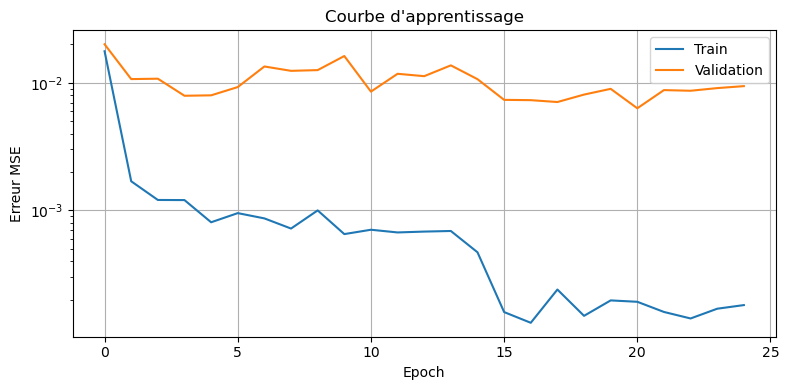

Meilleur modèle rechargé — val minimale : 0.006312


In [11]:
criterion  = nn.MSELoss()   # erreur quadratique moyenne
optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf") 
patience_compteur = 0        

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()                       # remet les gradients à zéro
        prediction = modele(X_batch)                 # prédiction
        perte      = criterion(prediction, y_batch)  # erreur
        perte.backward()                             # rétropropagation
        optimiseur.step()                            # mise à jour des poids
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

---
## Vérification

Évaluation sur 216,000 échantillons test


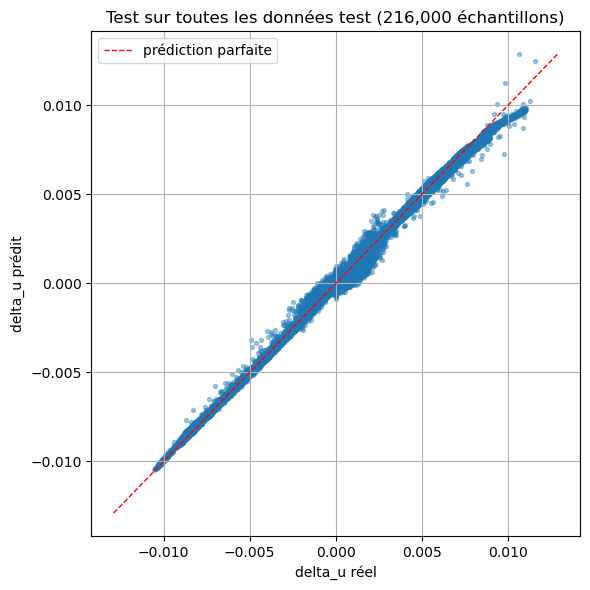

MSE : 1.3862e-08   |   R² : 0.9968


In [12]:
# --- 1. Filtrer les lignes test du dataset ---
df = pd.read_csv(DATASET_FILE)                              # à enlever si df déjà chargé
df_test = df[df["split"] == "test"].reset_index(drop=True)
print(f"Évaluation sur {len(df_test):,} échantillons test")

# --- 3. Extraire entrées (déjà normalisées dans le CSV) et sortie réelle ---
X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test["delta_u"].values                          # vérité terrain non normalisée

# --- 4. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy().squeeze()

# Dénormalisation de la sortie
mean_du = norm_stats.loc["delta_u", "mean"]
std_du  = norm_stats.loc["delta_u", "std"]
y_pred = y_pred_n * std_du + mean_du

# --- 5. Visualisation ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.4, s=8)
lim = max(abs(y_true).max(), abs(y_pred).max())
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
ax.set_xlabel("delta_u réel")
ax.set_ylabel("delta_u prédit")
ax.set_title(f"Test sur toutes les données test ({len(df_test):,} échantillons)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

mse = ((y_pred - y_true)**2).mean()
r2  = 1 - mse / y_true.var()
print(f"MSE : {mse:.4e}   |   R² : {r2:.4f}")

0.002245499999844469
0.11706899999990128


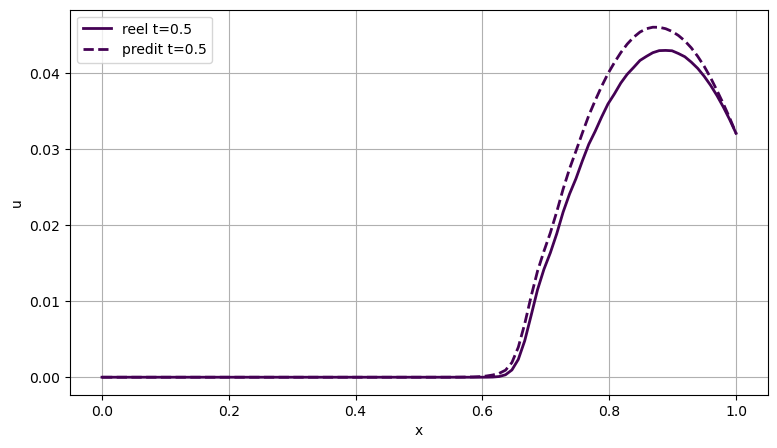

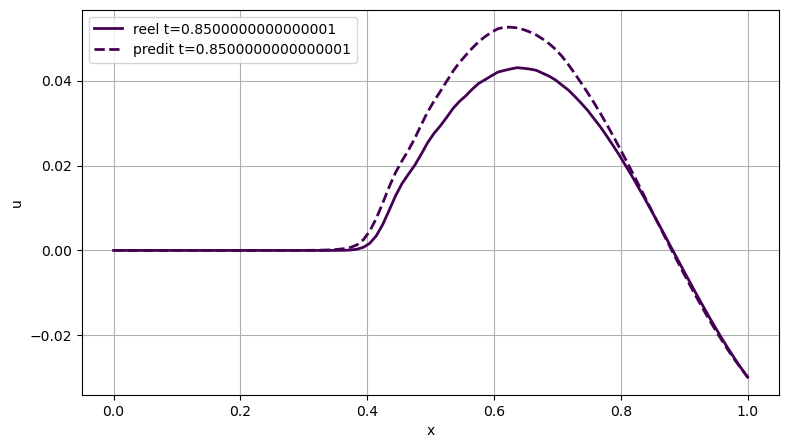

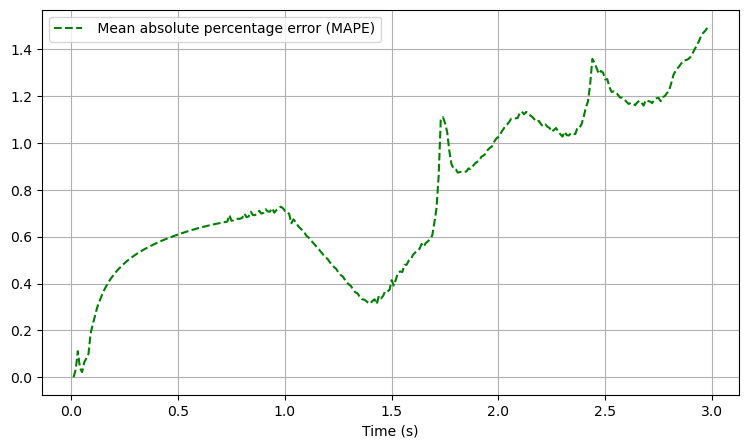

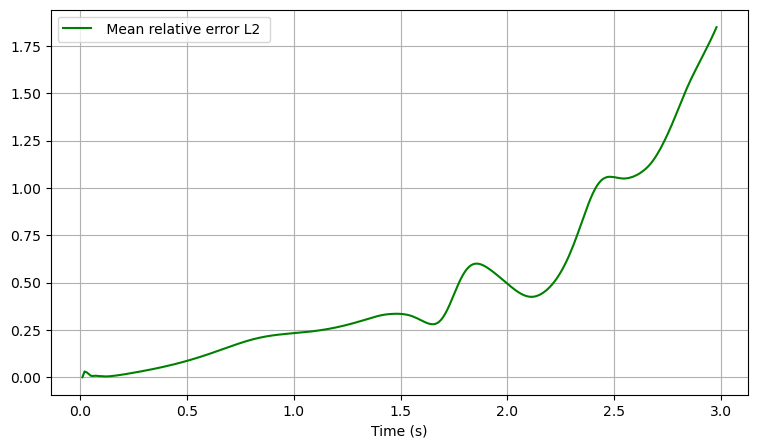

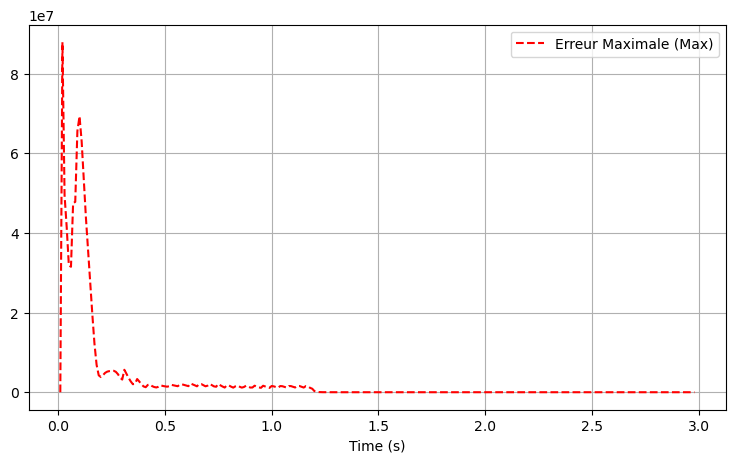

In [ ]:
# Roll Out

import time
from scipy.sparse import diags


A = AMPLITUDES[2]
omega = PULSATIONS[2]

dx = L / (Nx - 1)
dt = t_end / Nt
t_list = [0.5]
x = np.linspace(0, L, Nx)

stats_normalisation = {}
for name in INPUTS + OUTPUTS:
    stats_normalisation[name] = {
        "mean": norm_stats.loc[name, "mean"],
        "std" : norm_stats.loc[name, "std"]
    }

mu_du = stats_normalisation[OUTPUTS[0]]["mean"]
sd_du = stats_normalisation[OUTPUTS[0]]["std"]

feat_spec = []
for name in INPUTS:
    base, kstr = name.rsplit("_", 1)
    feat_spec.append((name, base, int(kstr)))

t_pulse = 2 * np.pi / omega
def u_right(t):
    return A * np.sin(omega * t) if t < t_pulse else 0.0

# =====================================================
# 1) VRAIE simulation (physique)
# =====================================================

start_time_phys = time.perf_counter()

v   = np.sqrt(E / rho)        # rho=2 ici, coherent avec le dataset
CFL = v * dt / dx

u   = np.zeros(Nx)
u_2 = np.zeros(Nx)
reel = {0.0: u.copy()}
for n in range(Nt):
    t = n * dt
    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_right(t+dt)
    u_2 = u.copy()
    u   = u_new
    reel[round((n+1)*dt, 5)] = u.copy()

time_phys = time.perf_counter() - start_time_phys

# =====================================================
# 2) Simulation PREDITE (reseau)
# =====================================================

start_time_pred = time.perf_counter()

Ntot = Nx+2*SS
u   = np.zeros(Ntot)
u_ndt = np.zeros(Ntot)
u_xx = np.zeros(Ntot)
u_tt = np.zeros(Ntot)

pred = {0.0: u[SS:Nx+SS].copy()}

noeuds = np.arange(SS,Nx+SS)
i_gauche = SS
i_droite = Nx + SS - 1

# Error initialisation

error_mape=[]
error_max=[]
error_l2_rel=[]
temps_sim = []

def l2_rel(u_pred, u_reel, eps=1e-12):
    return np.linalg.norm(u_pred - u_reel) / (np.linalg.norm(u_reel) + eps)

def smape (prediction, cible,eps=1e-12):
    mask = cible!= 0
    num=np.abs(cible[mask]-prediction[mask])*2
    den=np.abs(cible[mask]) +np.abs(prediction[mask])+eps
    return np.mean((num/den))

def errormax(cible, prediction,eps=1e-12):
    num = np.abs(cible-prediction)
    den = np.maximum(np.abs(cible), eps)
    return np.max((num/den))

def construire_entree(u_dot, u_xx):
    champs = {"u_dot": u_dot, "u_xx": u_xx}
    e = np.zeros((len(noeuds), len(feat_spec)), dtype=np.float32)
    for idx, (name, base, k) in enumerate(feat_spec):
        mu = stats_normalisation[name]["mean"]
        sd = stats_normalisation[name]["std"]
        e[:, idx] = (champs[base][noeuds + k] - mu) / sd
    return e

# Biais au repos : a u=0, tous les stencils valent 0 -> sortie identique partout (scalaire)
with torch.no_grad():
    entree_repos = construire_entree(np.zeros(Ntot), np.zeros(Ntot))
    sortie_repos = modele(torch.tensor(entree_repos)).numpy().ravel()
biais_rest = (sortie_repos * sd_du + mu_du)[0]    

# Roll out algorithm

u_tt_dict, u_xx_dict = {}, {}

for n in range(0, Nt-ndt-1, ndt):
    
    t = n * dt
    t_suivant = round((n+ndt)*dt, 5)

    u[:i_gauche]   = 0.0            
    u[i_droite+1:] = u[i_droite]    
    
    u_xx[1:-1] = (u[2:] + u[:-2] - 2*u[1:-1] ) / dx**2

    u_dot = (u - u_ndt) / (ndt*dt)                            

    t_actuel = round(n * dt, 5)
    
    u_xx_dict[t]  = u_xx[noeuds]

    entree = construire_entree(u_dot, u_xx)

    with torch.no_grad():
        sortie = modele(torch.tensor(entree)).numpy().ravel()
    
    delta_u = sortie * sd_du + mu_du - biais_rest

    u_new = np.zeros(Ntot)
    u_new[noeuds] = u[noeuds] + delta_u
    
    u_new[i_gauche]  = 0.0
    u_new[i_droite] = u_right(t_suivant)
    
    u_tt[1:-1] = (u[1:-1] - 2*u_ndt[1:-1] + u_1[1:-1]) / (ndt*dt)**2
    u_tt_dict[t] = u_tt[noeuds]

    u_ndt = u.copy()
    u   = u_new

    u_phys = u_new[noeuds]

    pred[t_suivant] = u_phys.copy()

    # Error computing
    u_reel_instante=reel[t_suivant]

    temps_sim.append(t_suivant)
    error_mape.append(smape(u_phys, u_reel_instante))
    error_max.append(errormax(u_reel_instante, u_phys))  
    error_l2_rel.append(l2_rel(u_phys, u_reel_instante))

time_pred = time.perf_counter() - start_time_pred

# Duration of the methods

print(time_phys)
print(time_pred)

# =====================================================
# 3) Trace
# ================================================

plt.figure(figsize=(9, 5))
for t, c in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color=c, lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color=c, lw=2, ls="--", label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)


plt.figure(figsize=(9, 5))
for t, c in zip([0.8+5*dt], plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color=c, lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color=c, lw=2, ls="--", label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)
# Plotting errors

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_mape, label=" Mean absolute percentage error (MAPE)", color="green", lw=1.5, ls="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_l2_rel, label=" Mean relative error L2 ", color="green", lw=1.5, ls="-")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_max, label="Erreur Maximale (Max)", color="red", lw=1.5, ls="--")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.show()

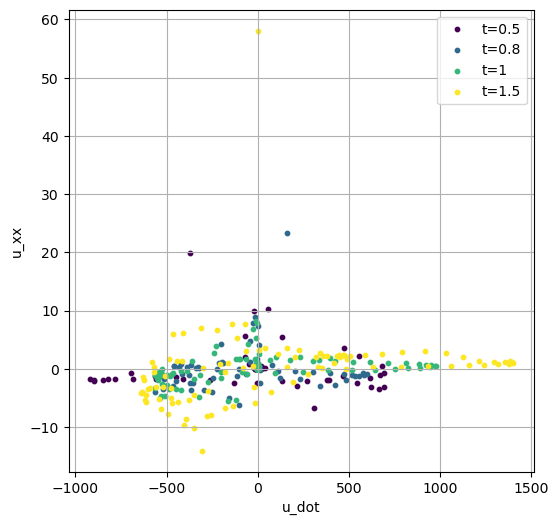

In [ ]:
# =====================================================
# 5) Visualisation of u_xx en fonction of u_dot 
# =====================================================

t_list_plot = [0.5, 0.8, 1, 1.5]
colors = plt.cm.viridis(np.linspace(0, 1, len(t_list_plot)))

plt.figure(figsize=(6, 6))

for t, c in zip(t_list_plot, colors):
    k = min(u_tt_dict, key=lambda key: abs(key - t))
    plt.scatter(u_tt_dict[k], u_xx_dict[k], color=c, label=f"t={t}", s=10)

plt.xlabel("u_tt")
plt.ylabel("u_xx")
plt.legend()
plt.grid(True)
plt.show()